<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QForce004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Initialization cell
import numpy as np
import matplotlib.pyplot as plt

N = 100
x = np.linspace(0, 2*np.pi, N)
omega = 1.0
epsilon = 0.01
alpha = 0.5

# Original field
field = epsilon * np.sin(omega * x)

# Local phase rotation
theta = alpha * np.sin(omega * x)
rotated_field = field * np.cos(theta)

# Store both fields
original_history = [field.copy()]
rotated_history = [rotated_field.copy()]


In [2]:
# Propagation cell
def evolve(lattice, c=1.0, dt=0.1):
    new = lattice.copy()
    for i in range(1, len(lattice)-1):
        new[i] = lattice[i] + c*dt*(lattice[i+1] - 2*lattice[i] + lattice[i-1])
    return new

for t in range(1000):
    field = evolve(field)
    rotated_field = evolve(rotated_field)
    if t % 50 == 0:
        original_history.append(field.copy())
        rotated_history.append(rotated_field.copy())


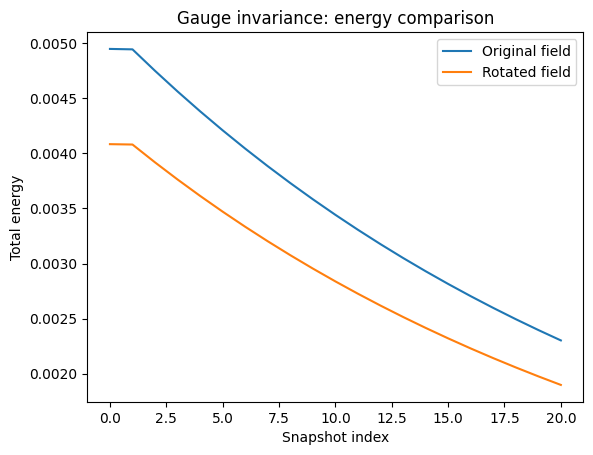

In [3]:
# Energy comparison
energy_orig = [np.sum(h**2) for h in original_history]
energy_rot = [np.sum(h**2) for h in rotated_history]

plt.plot(energy_orig, label="Original field")
plt.plot(energy_rot, label="Rotated field")
plt.xlabel("Snapshot index")
plt.ylabel("Total energy")
plt.title("Gauge invariance: energy comparison")
plt.legend()
plt.show()


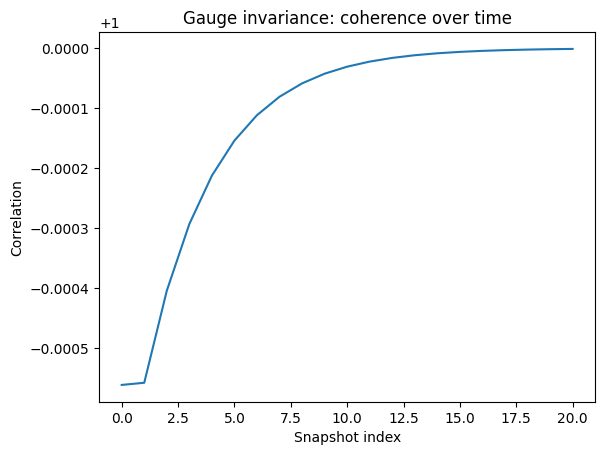

In [4]:
# Coherence metric
def correlation(a, b):
    return np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b))

coherence = [correlation(original_history[i], rotated_history[i]) for i in range(len(original_history))]

plt.plot(range(len(coherence)), coherence)
plt.xlabel("Snapshot index")
plt.ylabel("Correlation")
plt.title("Gauge invariance: coherence over time")
plt.show()
